In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from utilities import load_beer_data

In [3]:
df = load_beer_data()
df = df.replace("", pd.NA)
df.head()

,Name,Brewery,Style,ABV,IBU,Calories,Carbs,Rating,Notes,main_style,sub_style
0,Kolsch Style,Best Day Brewing,Kolsch,0.005,<NA>,55,11.0,4,NaN,Kolsch,NaN
1,Hazy IPA,Best Day Brewing,IPA (Hazy),0.005,<NA>,53,11.0,3,Much more bitter than other hazy IPAs,IPA,Hazy
2,West Coast IPA,Best Day Brewing,IPA (West Coast),0.005,<NA>,68,11.0,4,NaN,IPA,West Coast
3,Electro-Lime,Best Day Brewing,Lager (Mexican),0.005,<NA>,75,14.0,2,NaN,Lager,Mexican
4,Upside Dawn,Athletic Brewing Company,Lager (Golden),0.005,25,45,10.0,5,"Refreshing hint of bitterness, gluten-removed",Lager,Golden


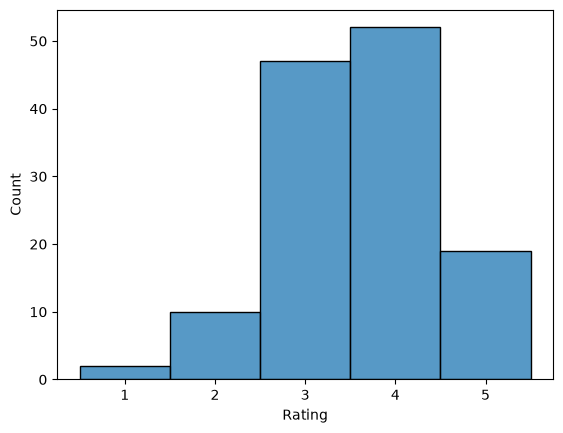

In [3]:
# Distribution of ratings
sns.histplot(x=df["Rating"], discrete=True);

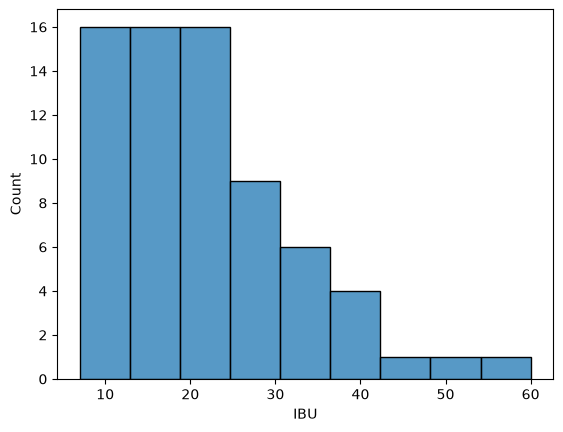

In [4]:
sns.histplot(x=df["IBU"]);

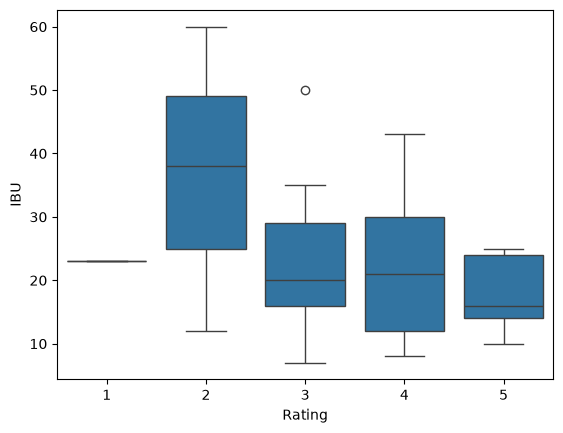

In [5]:
sns.boxplot(df, x="Rating", y="IBU");

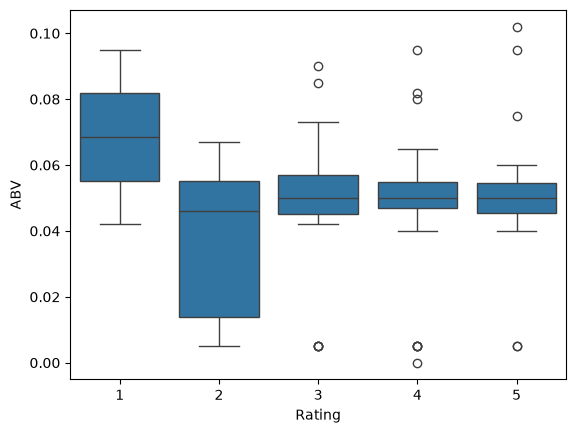

In [6]:
sns.boxplot(df, x="Rating", y="ABV");

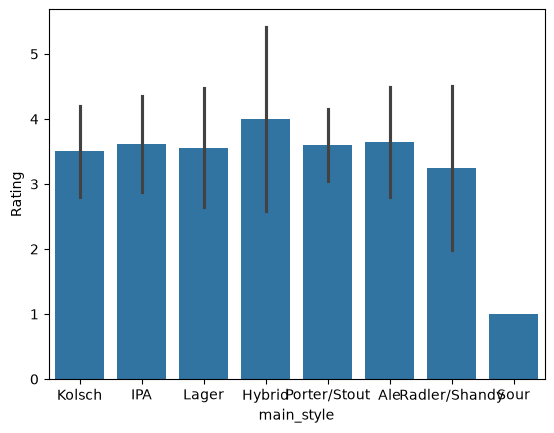

In [7]:
# rating_by_style = df.groupby("main_style", dropna=True)["Rating"].agg(["mean", "std"]).reset_index()
sns.barplot(data=df, x="main_style", y="Rating", estimator="mean", errorbar="sd");

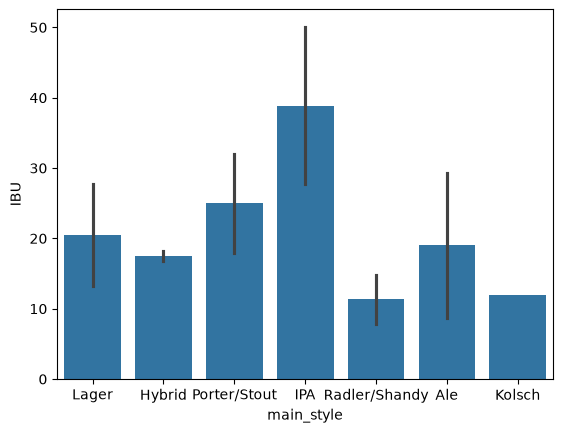

In [8]:
sns.barplot(
    data=df.dropna(subset=["main_style", "IBU"]),
    x="main_style",
    y="IBU",
    estimator="mean",
    errorbar="sd",
);

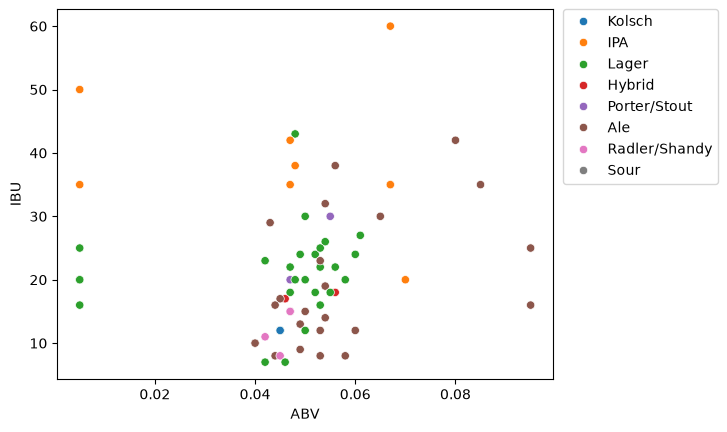

In [9]:
sns.scatterplot(df, x="ABV", y="IBU", hue="main_style")
# Move legend outside of plot
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0);

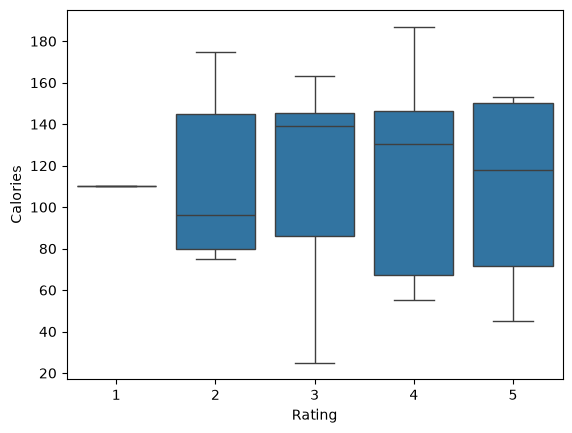

In [10]:
# How much "value" am I getting for the calories I drink?
sns.boxplot(data=df, x="Rating", y="Calories");

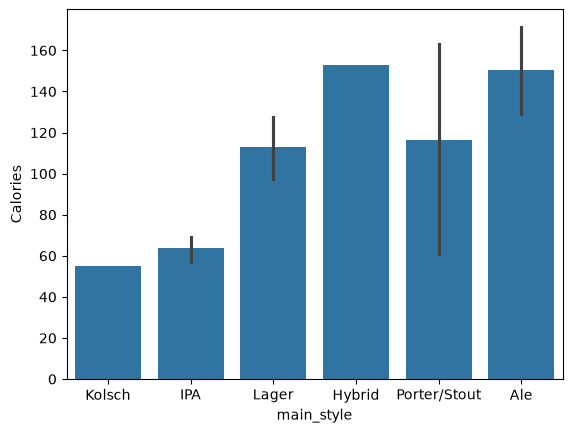

In [11]:
sns.barplot(
    data=df.dropna(subset=["main_style", "Calories"]),
    x="main_style",
    y="Calories",
    estimator="mean",
    errorbar=("ci", 95),
);

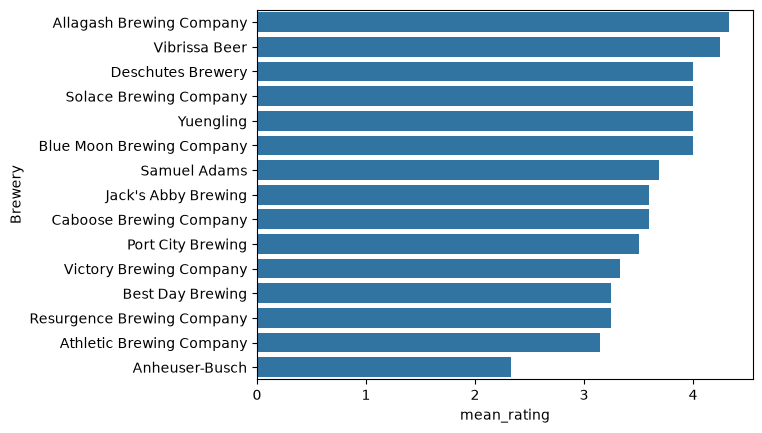

In [22]:
# Brewery ratings
# Group by breweries with at least 3 reviews, exclude all others
# breweries = df.groupby("Brewery").agg(mean_rating=("Rating", "mean"), ci_95="ADD 95% CONFIDENCE INTERVAL FOR BARPLOT")
breweries = df.groupby("Brewery").agg(count=("Rating", "size"), mean_rating=("Rating", "mean"))
breweries3 = breweries[breweries["count"] > 2]
sns.barplot(data=breweries3, 
            y="Brewery", 
            x="mean_rating", 
            order=breweries3.sort_values("mean_rating", ascending=False).index);